# 🚀 Diabetes prediction — Boosting (XGBoost)

## 00 Librerias

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, roc_auc_score, roc_curve
from pickle import dump, load
import warnings
warnings.filterwarnings('ignore')

## Paso 1: Carga del conjunto de datos procesado

In [4]:



# Cargamos los datos procesados del proyecto anterior
train_data = pd.read_csv("../data/processed/train_data.csv")
test_data  = pd.read_csv("../data/processed/test_data.csv")

print(f"Train: {train_data.shape}  |  Test: {test_data.shape}")
train_data.head()


Train: (614, 7)  |  Test: (154, 7)


,Pregnancies,Glucose,SkinThickness,Insulin,BMI,Age,Outcome
0,1.0,90.0,14.5,112.875,27.2,24.0,0
1,5.0,126.0,27.0,112.875,29.6,40.0,0
2,2.0,105.0,40.0,112.875,34.9,25.0,0
3,1.0,146.0,29.0,125.000,29.7,29.0,0
4,0.0,95.0,39.0,112.875,44.6,22.0,0


In [5]:
# Separamos variables predictoras y variable objetivo
X_train = train_data.drop(["Outcome"], axis=1)
y_train = train_data["Outcome"]
X_test  = test_data.drop(["Outcome"], axis=1)
y_test  = test_data["Outcome"]

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)


X_train: (614, 6)
X_test:  (154, 6)


## Paso 2: Modelo Boosting

### 2.1 Modelo base (igual que la solución de referencia)

In [6]:
# Cargamos también los modelos anteriores para comparar al final
arbol = DecisionTreeClassifier(random_state=42)
arbol.fit(X_train, y_train)
acc_arbol = accuracy_score(y_test, arbol.predict(X_test))

rf = RandomForestClassifier(n_estimators=60, random_state=42)
rf.fit(X_train, y_train)
acc_rf = accuracy_score(y_test, rf.predict(X_test))

print(f"Árbol de Decisión  (referencia): {acc_arbol:.4f}")
print(f"Random Forest      (referencia): {acc_rf:.4f}")


Árbol de Decisión  (referencia): 0.6948
Random Forest      (referencia): 0.7143


In [7]:
# XGBoost base — igual que la solución
model = XGBClassifier(n_estimators=200, learning_rate=0.001, random_state=42)
model.fit(X_train, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes 

In [8]:
y_pred = model.predict(X_test)
y_pred


array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [9]:
acc_base = accuracy_score(y_test, y_pred)
print(f"Accuracy XGBoost base: {acc_base:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))


Accuracy XGBoost base: 0.6494

              precision    recall  f1-score   support

 No diabetes       0.65      1.00      0.79       100
    Diabetes       0.00      0.00      0.00        54

    accuracy                           0.65       154
   macro avg       0.32      0.50      0.39       154
weighted avg       0.42      0.65      0.51       154



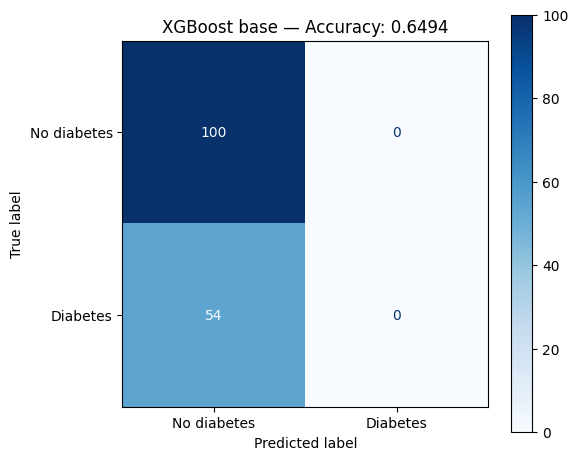

In [10]:
# Matriz de confusion
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["No diabetes", "Diabetes"])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap="Blues")
ax.set_title(f"XGBoost base — Accuracy: {acc_base:.4f}")
plt.tight_layout()
plt.show()


> **This boosting algorithm is better than the optimized decision tree.**


### 2.2 Impacto de n_estimators — número de árboles en la secuencia

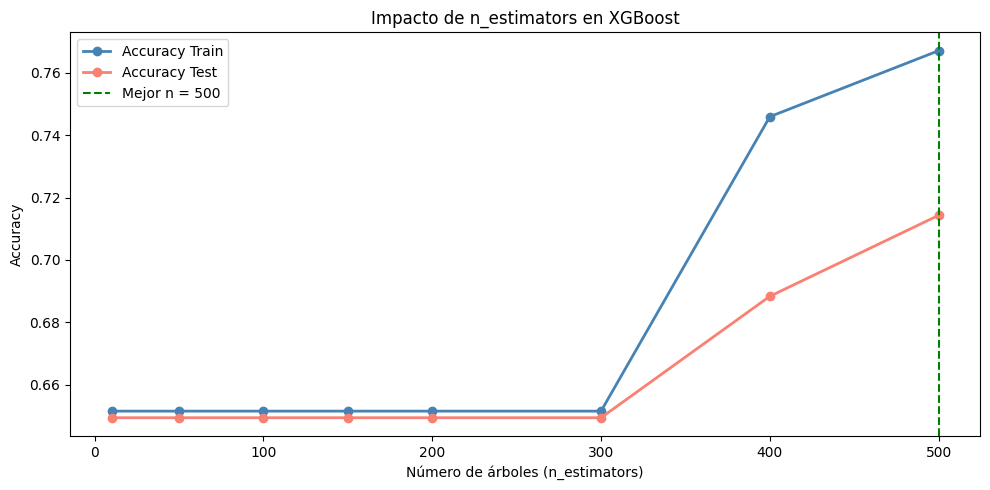

Mejor n_estimators: 500  ->  Accuracy Test: 0.7143


In [11]:
n_vals = [10, 50, 100, 150, 200, 300, 400, 500]
acc_train_n, acc_test_n = [], []

for n in n_vals:
    m = XGBClassifier(n_estimators=n, learning_rate=0.001, random_state=42)
    m.fit(X_train, y_train)
    acc_train_n.append(accuracy_score(y_train, m.predict(X_train)))
    acc_test_n.append(accuracy_score(y_test,  m.predict(X_test)))

plt.figure(figsize=(10, 5))
plt.plot(n_vals, acc_train_n, "o-", color="steelblue", lw=2, label="Accuracy Train")
plt.plot(n_vals, acc_test_n,  "o-", color="salmon",    lw=2, label="Accuracy Test")
mejor_n = n_vals[np.argmax(acc_test_n)]
plt.axvline(mejor_n, color="green", linestyle="--", label=f"Mejor n = {mejor_n}")
plt.xlabel("Número de árboles (n_estimators)")
plt.ylabel("Accuracy")
plt.title("Impacto de n_estimators en XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Mejor n_estimators: {mejor_n}  ->  Accuracy Test: {max(acc_test_n):.4f}")


### 2.3 Impacto de `learning_rate` — tasa de aprendizaje

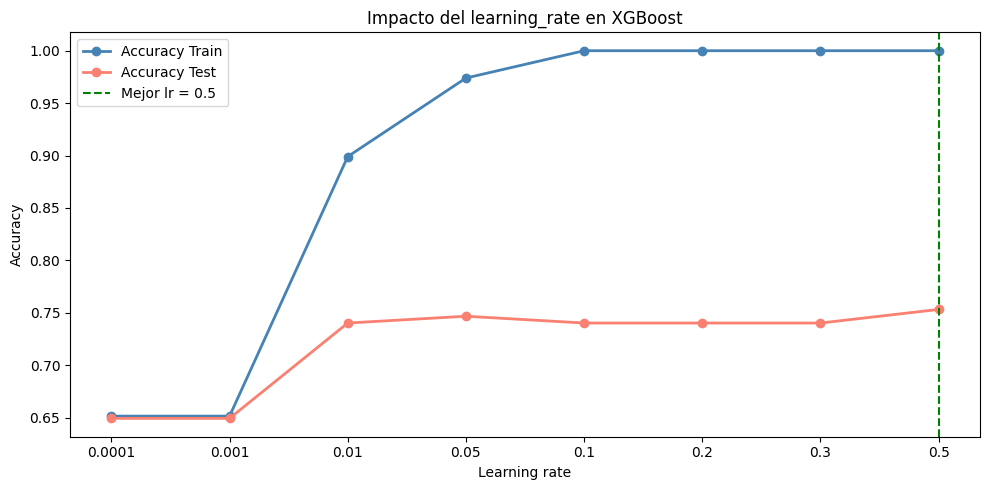

Mejor learning_rate: 0.5  ->  Accuracy Test: 0.7532


In [20]:
lr_vals = [0.0001, 0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5]
acc_train_lr, acc_test_lr = [], []

for lr in lr_vals:
    m = XGBClassifier(n_estimators=200, learning_rate=lr, random_state=42)
    m.fit(X_train, y_train)
    acc_train_lr.append(accuracy_score(y_train, m.predict(X_train)))
    acc_test_lr.append(accuracy_score(y_test,  m.predict(X_test)))

etiquetas_lr = [str(lr) for lr in lr_vals]
plt.figure(figsize=(10, 5))
plt.plot(etiquetas_lr, acc_train_lr, "o-", color="steelblue", lw=2, label="Accuracy Train")
plt.plot(etiquetas_lr, acc_test_lr,  "o-", color="salmon",    lw=2, label="Accuracy Test")
mejor_lr_idx = np.argmax(acc_test_lr)
plt.axvline(etiquetas_lr[mejor_lr_idx], color="green", linestyle="--",
            label=f"Mejor lr = {lr_vals[mejor_lr_idx]}")
plt.xlabel("Learning rate")
plt.ylabel("Accuracy")
plt.title("Impacto del learning_rate en XGBoost")
plt.legend()
plt.tight_layout()
plt.show()

mejor_lr = lr_vals[mejor_lr_idx]
print(f"Mejor learning_rate: {mejor_lr}  ->  Accuracy Test: {max(acc_test_lr):.4f}")


### 2.4 Mapa de calor: n_estimators × learning_rate

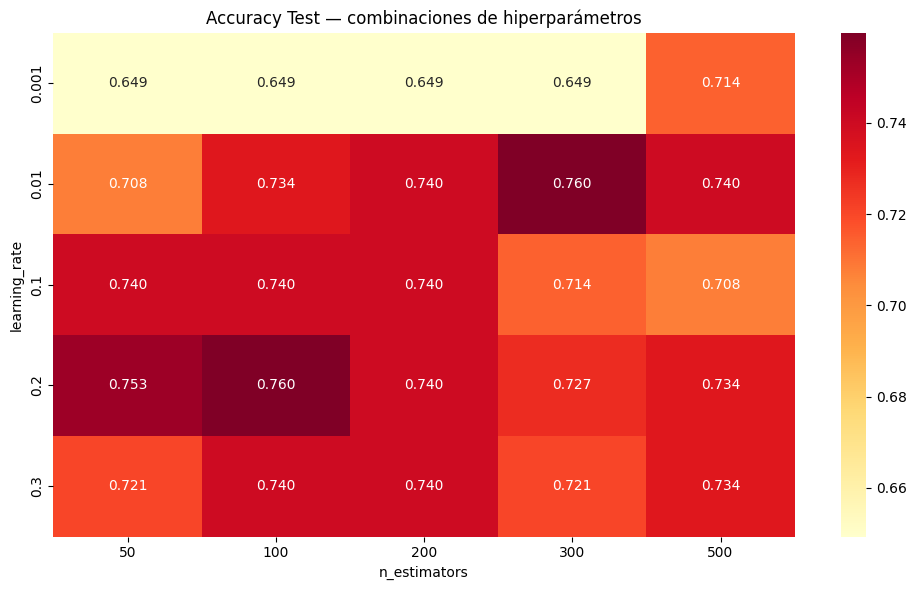

Mejor combinacion:
  n_estimators = 300
  learning_rate = 0.01
  Accuracy = 0.7597


In [13]:
n_grid  = [50, 100, 200, 300, 500]
lr_grid = [0.001, 0.01, 0.1, 0.2, 0.3]

matriz_acc = np.zeros((len(lr_grid), len(n_grid)))

for i, lr in enumerate(lr_grid):
    for j, n in enumerate(n_grid):
        m = XGBClassifier(n_estimators=n, learning_rate=lr, random_state=42)
        m.fit(X_train, y_train)
        matriz_acc[i, j] = accuracy_score(y_test, m.predict(X_test))

plt.figure(figsize=(10, 6))
sns.heatmap(matriz_acc, annot=True, fmt=".3f", cmap="YlOrRd",
            xticklabels=n_grid, yticklabels=lr_grid)
plt.xlabel("n_estimators")
plt.ylabel("learning_rate")
plt.title("Accuracy Test — combinaciones de hiperparámetros")
plt.tight_layout()
plt.show()

idx = np.unravel_index(np.argmax(matriz_acc), matriz_acc.shape)
best_n  = n_grid[idx[1]]
best_lr = lr_grid[idx[0]]
print(f"Mejor combinacion:")
print(f"  n_estimators = {best_n}")
print(f"  learning_rate = {best_lr}")
print(f"  Accuracy = {matriz_acc[idx]:.4f}")


### 2.5 Modelo optimizado con los mejores hiperparámetros

In [14]:
model_opt = XGBClassifier(
    n_estimators=best_n,
    learning_rate=best_lr,
    random_state=42
)
model_opt.fit(X_train, y_train)

y_pred_opt = model_opt.predict(X_test)
acc_opt    = accuracy_score(y_test, y_pred_opt)

print(f"Accuracy XGBoost optimizado: {acc_opt:.4f}")
print(f"Accuracy XGBoost base:       {acc_base:.4f}")
print()
print(classification_report(y_test, y_pred_opt, target_names=["No diabetes", "Diabetes"]))


Accuracy XGBoost optimizado: 0.7597
Accuracy XGBoost base:       0.6494

              precision    recall  f1-score   support

 No diabetes       0.81      0.83      0.82       100
    Diabetes       0.67      0.63      0.65        54

    accuracy                           0.76       154
   macro avg       0.74      0.73      0.73       154
weighted avg       0.76      0.76      0.76       154



## Paso 3: Guardado del modelo

In [21]:
import os
os.makedirs("../models", exist_ok=True)

dump(model_opt, open(f"../models/boosting_classifier_nestimators-{best_n}_learnrate-{best_lr}_42.sav", "wb"))
print(f"✅ Modelo guardado en: ../models/boosting_classifier_nestimators-{best_n}_learnrate-{best_lr}_42.sav")


✅ Modelo guardado en: ../models/boosting_classifier_nestimators-300_learnrate-0.01_42.sav


## Paso 4: Comparativa final de los tres modelos

Ahora comparamos el árbol de decisión, el Random Forest y el XGBoost
para decidir cuál es el mejor para predecir la diabetes.


In [22]:
# Predicciones de los tres modelos
y_pred_arbol = arbol.predict(X_test)
y_pred_rf    = rf.predict(X_test)
y_pred_xgb   = model_opt.predict(X_test)

# Métricas de los tres modelos
from sklearn.metrics import precision_score, recall_score, f1_score

def metricas(y_true, y_pred, nombre):
    return {
        "Modelo": nombre,
        "Accuracy":  round(accuracy_score(y_true, y_pred), 4),
        "Precision (No diab)": round(precision_score(y_true, y_pred, pos_label=0), 4),
        "Recall (No diab)":    round(recall_score(y_true, y_pred, pos_label=0), 4),
        "Precision (Diab)":    round(precision_score(y_true, y_pred, pos_label=1), 4),
        "Recall (Diab)":       round(recall_score(y_true, y_pred, pos_label=1), 4),
        "F1 (Diab)":           round(f1_score(y_true, y_pred, pos_label=1), 4),
    }

tabla = pd.DataFrame([
    metricas(y_test, y_pred_arbol, "Árbol de Decisión"),
    metricas(y_test, y_pred_rf,    "Random Forest"),
    metricas(y_test, y_pred_xgb,   "XGBoost (Boosting)"),
])

print(tabla.to_string(index=False))


            Modelo  Accuracy  Precision (No diab)  Recall (No diab)  Precision (Diab)  Recall (Diab)  F1 (Diab)
 Árbol de Decisión    0.6948               0.7624              0.77            0.5660         0.5556     0.5607
     Random Forest    0.7143               0.7692              0.80            0.6000         0.5556     0.5769
XGBoost (Boosting)    0.7597               0.8058              0.83            0.6667         0.6296     0.6476


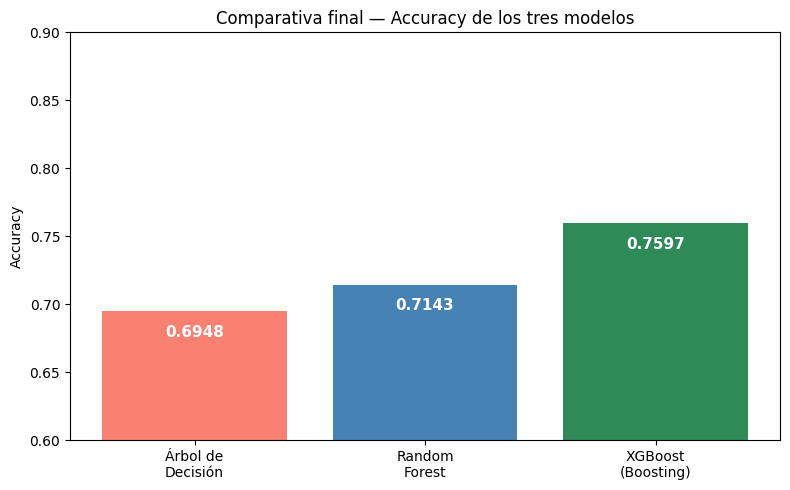

In [23]:
# Gráfico comparativo de Accuracy
modelos = ["Árbol de\nDecisión", "Random\nForest", "XGBoost\n(Boosting)"]
accs    = [acc_arbol, acc_rf, acc_opt]
colores = ["salmon", "steelblue", "seagreen"]

plt.figure(figsize=(8, 5))
bars = plt.bar(modelos, accs, color=colores)
plt.ylim(0.60, 0.90)
plt.ylabel("Accuracy")
plt.title("Comparativa final — Accuracy de los tres modelos")
for bar, v in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() - 0.01,
             f"{v:.4f}", ha="center", va="top",
             color="white", fontweight="bold", fontsize=11)
plt.tight_layout()
plt.show()


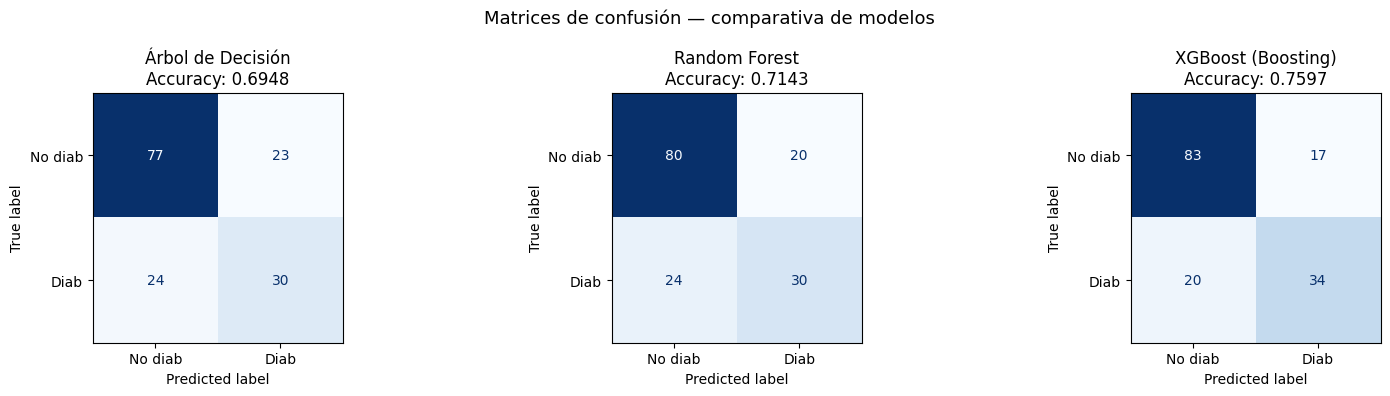

In [24]:
# Matrices de confusion de los tres modelos
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, y_p, titulo, acc in zip(
    axes,
    [y_pred_arbol, y_pred_rf, y_pred_xgb],
    ["Árbol de Decisión", "Random Forest", "XGBoost (Boosting)"],
    [acc_arbol, acc_rf, acc_opt]
):
    cm = confusion_matrix(y_test, y_p)
    ConfusionMatrixDisplay(cm, display_labels=["No diab", "Diab"]).plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{titulo}\nAccuracy: {acc:.4f}")

plt.suptitle("Matrices de confusión — comparativa de modelos", fontsize=13)
plt.tight_layout()
plt.show()


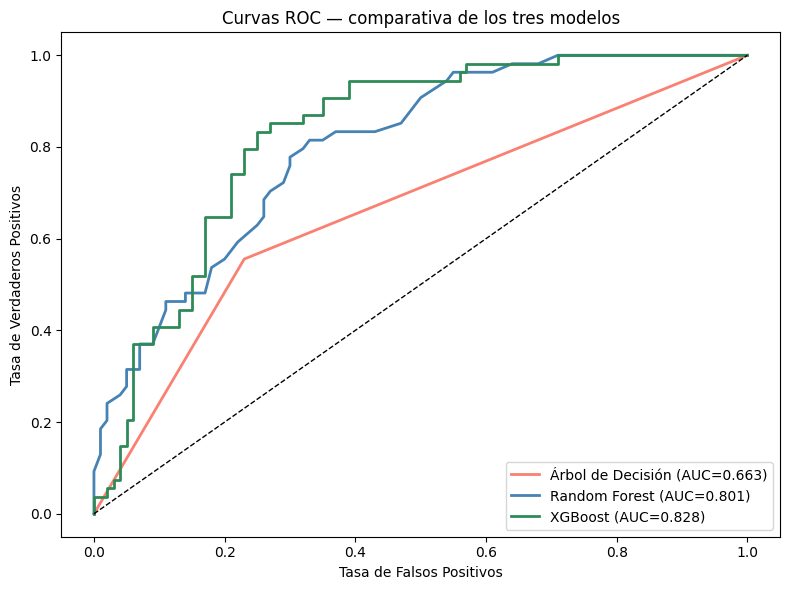

In [25]:
# Curvas ROC de los tres modelos
plt.figure(figsize=(8, 6))

for nombre, modelo, color in [
    ("Árbol de Decisión", arbol,     "salmon"),
    ("Random Forest",     rf,        "steelblue"),
    ("XGBoost",           model_opt, "seagreen"),
]:
    y_prob = modelo.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, lw=2, color=color, label=f"{nombre} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], "k--", lw=1)
plt.xlabel("Tasa de Falsos Positivos")
plt.ylabel("Tasa de Verdaderos Positivos")
plt.title("Curvas ROC — comparativa de los tres modelos")
plt.legend()
plt.tight_layout()
plt.show()


En los tres modelos la clase con más precisión es No diabetes (0)
y la que menos es Diabetes (1), lo cual se explica porque hay más
pacientes sin diabetes en el dataset (desbalance de clases).

Si tuviéramos que elegir uno solo, nos quedaríamos con **XGBoost** por
su mejor rendimiento general, especialmente en el recall de la clase
positiva (diabetes), que es la más importante desde el punto de vista médico.
